In [1]:
import os
import re
import json
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
global_path = r"C:\Users\es25591\Box\myBox\Dataset"

focus = {
    "05": os.path.join(global_path, "2026-03-14_10-17/"),
    "10": os.path.join(global_path, "2026-03-14_11-31/"),
    "15": os.path.join(global_path, "2026-03-14_14-26/"),
    "20": os.path.join(global_path, "2026-03-14_15-24/"),
    "25": os.path.join(global_path, "2026-03-14_16-47/"),
}

pantelis = {
    "05": os.path.join(global_path, "2026-03-16_12-15/"),
    "10": os.path.join(global_path, "2026-03-16_11-29/"),
    "15": os.path.join(global_path, "2026-03-16_13-32/"),
    "20": os.path.join(global_path, "2026-03-16_14-34/"),
    "25": os.path.join(global_path, "2026-03-16_15-47/"),
}

pattern = re.compile(r"^debug_ep(\d+)\.json$")

def load_metrics_from_folder(folder_path):

    if not os.path.isdir(folder_path):
        print(f"Warning: Folder not found: {folder_path}")
        return None
    
    records = []
    for file_name in os.listdir(folder_path):
        match = pattern.match(file_name)
        if not match:
            continue

        episode_index = int(match.group(1))
        file_path = os.path.join(folder_path, file_name)

        try:
            with open(file_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            if isinstance(data, dict):
                records.append({"episode_index": episode_index, **data})
            else:
                records.append({"episode_index": episode_index, "data": data})
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue
    
    if records:
        records.sort(key=lambda x: x["episode_index"])
        return pd.DataFrame(records)
    return None

def get_avg_per_episode(col_name, df):
    """Extract average values per episode"""
    if df is None or col_name not in df.columns:
        return None
    return [sum(val)/len(val) if isinstance(val, list) else val 
            for val in df[col_name]]

# Load data for all capacities
def analyze_dataset(dataset_dict, dataset_name):
    """Analyze a dataset across all capacities"""
    capacities = sorted(dataset_dict.keys())
    hit_rates_per_capacity = []
    
    for capacity in capacities:
        df = load_metrics_from_folder(dataset_dict[capacity])
        
        if df is not None and 'base_layer_miss' in df.columns:
            # Convert miss rates to hit rates
            miss_avg = get_avg_per_episode('cache_misses', df)
            
            # miss_enh_1_avg = get_avg_per_episode('enh_layer_missing_1', df)
            # miss_enh_2_avg = get_avg_per_episode('enh_layer_missing_2', df)
            # miss_enh_3_avg = get_avg_per_episode('enh_layer_missing_3', df)
            # miss_enh_4_avg = get_avg_per_episode('enh_layer_missing_4', df)
            
            # miss_avg = [(miss*12 + enh1 + enh2 + enh3 + enh4)/16 for miss, enh1, enh2, enh3, enh4 in zip(miss_avg, miss_enh_1_avg, miss_enh_2_avg, miss_enh_3_avg, miss_enh_4_avg)]

            # hit_avg = [1 - miss for miss in miss_avg]
            hit_avg = get_avg_per_episode('cache_hits', df)
            
            final_hit_rate = sum(hit_avg) / len(hit_avg)  # Mean hit rate
            
            hit_rates_per_capacity.append(final_hit_rate)
            print(f"{dataset_name} - Capacity {capacity}: Hit Rate = {final_hit_rate:.4f}")
        else:
            print(f"{dataset_name} - Capacity {capacity}: No data or missing 'base_layer_miss'")
            hit_rates_per_capacity.append(None)
    
    return capacities, hit_rates_per_capacity

# Analyze both datasets
focus_caps, focus_hits = analyze_dataset(focus, "Focus")
pantelis_caps, pantelis_hits = analyze_dataset(pantelis, "Pantelis")


Focus - Capacity 05: Hit Rate = 6.1391
Focus - Capacity 10: Hit Rate = 7.7410
Focus - Capacity 15: Hit Rate = 10.2459
Focus - Capacity 20: Hit Rate = 10.6483
Focus - Capacity 25: Hit Rate = 10.9786
Pantelis - Capacity 05: Hit Rate = 19496.6430
Pantelis - Capacity 10: Hit Rate = 33579.0147
Pantelis - Capacity 15: Hit Rate = 44259.5060
Pantelis - Capacity 20: Hit Rate = 54323.8464
Pantelis - Capacity 25: Hit Rate = 63378.9232


In [3]:

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(focus_caps))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], focus_hits, width, label='Focus', alpha=0.8, color='#1f77b4')
bars2 = ax.bar([i + width/2 for i in x], pantelis_hits, width, label='Pantelis', alpha=0.8, color='#ff7f0e')

ax.set_xlabel('Cache Capacity', fontweight='bold', fontsize=12)
ax.set_ylabel('Average Cache Hit Rate', fontweight='bold', fontsize=12)
ax.set_title('Cache Hit Rate Comparison Across Different Capacities', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(focus_caps)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height is not None:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Comparison plot generated successfully!")

C:\Users\es25591\AppData\Local\Temp\ipykernel_11756\2148945532.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


ValueError: Image size of 850x29281142 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1000x600 with 1 Axes>


✓ Comparison plot generated successfully!


# Cache Hit Rate Comparison

This visualization compares the average cache hit rates across different cache capacities (5%, 10%, 15%, 20%, and 25%) for two datasets: **Focus** and **Pantelis**.

Selected file: c:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-17_10-45\debug_ep1.json


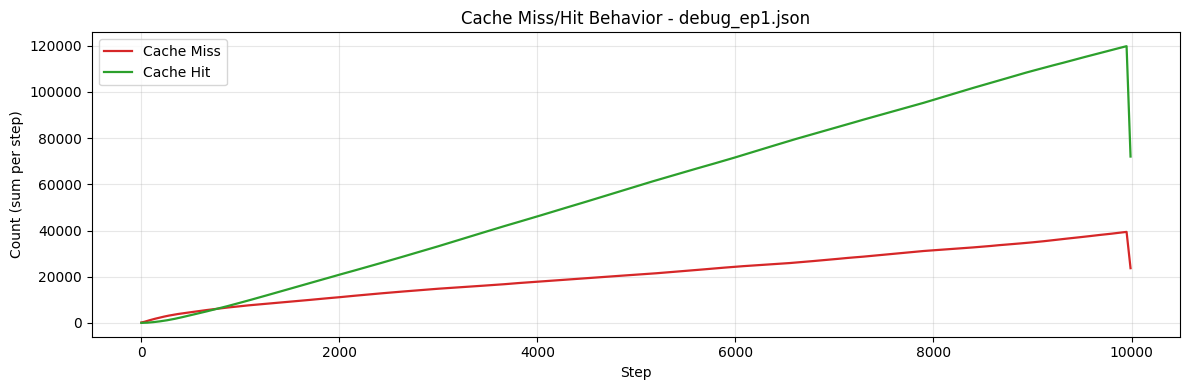

In [4]:
import random
import numpy as np

def to_scalar_per_step(values, reduction="sum"):
    """Convert nested cache-miss/hit data to a clean 1D numeric sequence."""
    if not isinstance(values, list):
        values = [values]
    try:
        arr = np.asarray(values, dtype=float)
        if arr.ndim == 1:
            return arr
        if arr.ndim >= 2:
            return arr.mean(axis=1) if reduction == "mean" else arr.sum(axis=1)
    except Exception:
        pass
    y = []
    for v in values:
        if isinstance(v, (list, tuple, np.ndarray)):
            y.append(float(sum(v) / len(v)) if reduction == "mean" else float(sum(v)))
        else:
            y.append(float(v))
    return np.asarray(y, dtype=float)


def moving_average(y, window=50):
    if window <= 1 or len(y) < window:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


def plot_random_cache_miss(
    global_path,
    filename,
    pattern=r"^debug_ep(\d+)\.json$",
    reduction="sum",
    smooth_window=100,
    sample_every=10,
):
    folder_path = os.path.join(global_path, filename)

    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    file_pattern = re.compile(pattern)
    candidates = [f for f in os.listdir(folder_path) if file_pattern.match(f)]

    if not candidates:
        raise FileNotFoundError(f"No files matching pattern '{pattern}' in: {folder_path}")

    chosen_file = random.choice(candidates)
    chosen_path = os.path.join(folder_path, chosen_file)
    print(f"Selected file: {chosen_path}")

    with open(chosen_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    cache_miss = data.get("cache_misses") or data.get("cache_miss")
    cache_hits  = data.get("cache_hits")  or data.get("cache_hit")

    if cache_miss is None:
        raise KeyError(f"'cache_misses'/'cache_miss' not found in {chosen_file}")

    # Collapse nested lists → one scalar per step, then smooth
    y_miss = moving_average(to_scalar_per_step(cache_miss, reduction), smooth_window)
    step = max(1, sample_every)
    x = np.arange(len(y_miss))[::step]
    y_miss_plot = y_miss[::step]

    plt.figure(figsize=(12, 4))
    plt.plot(x, y_miss_plot, color="#d62728", linewidth=1.6, label="Cache Miss")

    if cache_hits is not None:
        y_hits = moving_average(to_scalar_per_step(cache_hits, reduction), smooth_window)
        plt.plot(x, y_hits[::step], color="#2ca02c", linewidth=1.6, label="Cache Hit")

    plt.title(f"Cache Miss/Hit Behavior - {chosen_file}")
    plt.xlabel("Step")
    plt.ylabel(f"Count ({'mean' if reduction == 'mean' else 'sum'} per step)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


global_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
filename = "2026-03-17_10-45"

plot_random_cache_miss(
    global_path,
    filename,
    reduction="sum",
    smooth_window=100,
    sample_every=10,
)


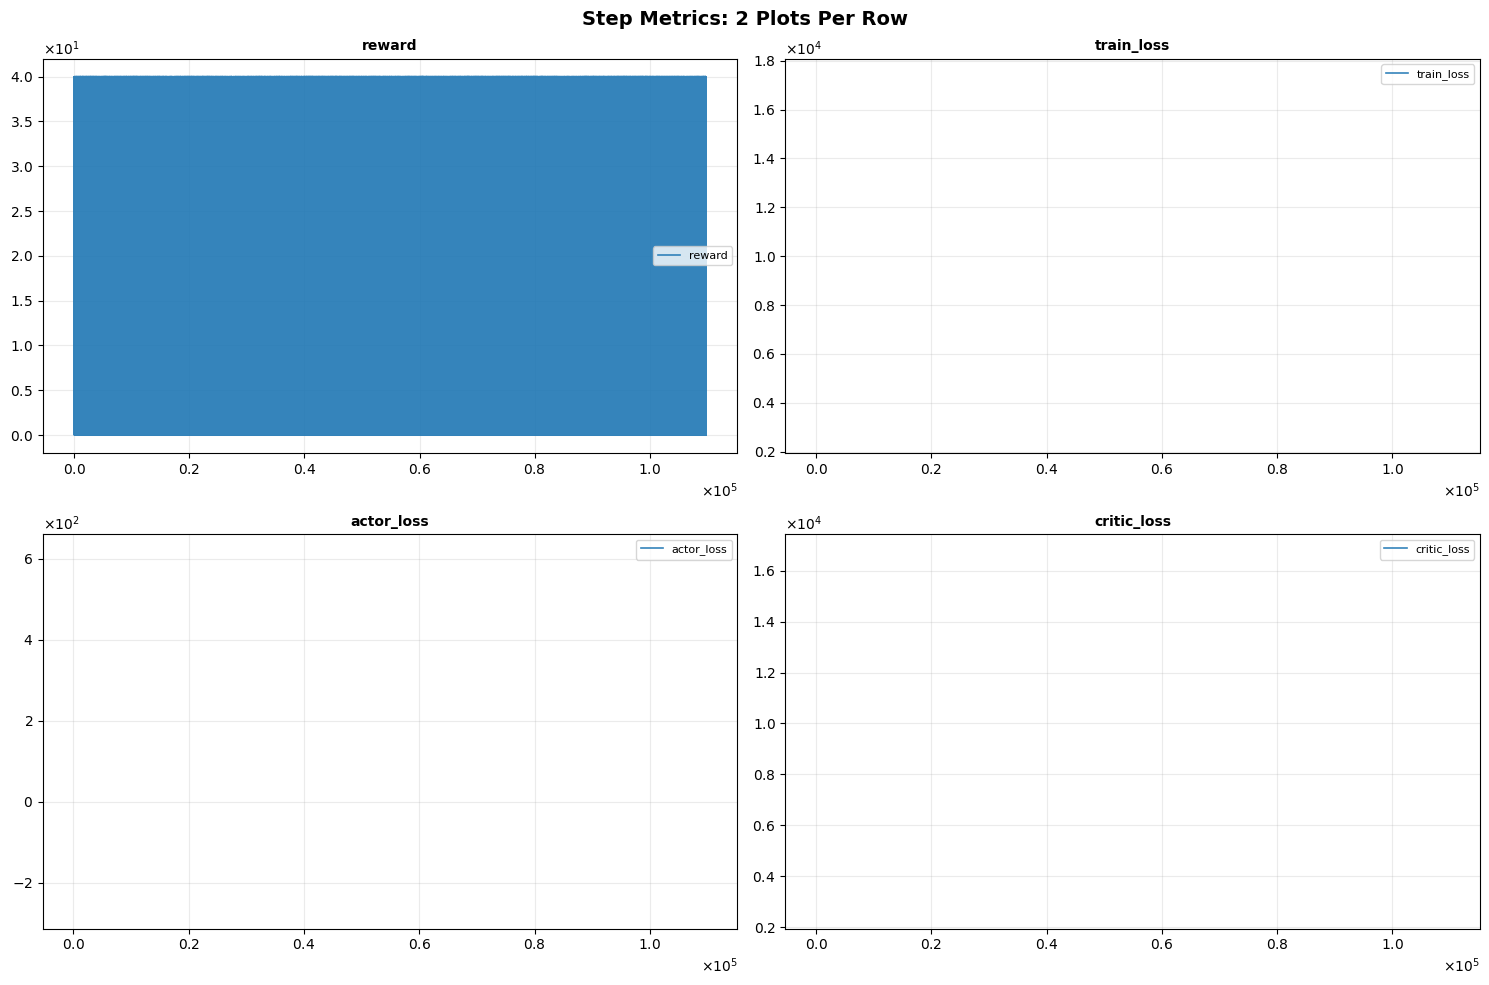

In [99]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

global_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
csv_path = os.path.join(global_path, "2026-04-02_12-03", "metrics", "step_metrics.csv")
df = pd.read_csv(csv_path)

# Choose x-axis
x_col = "global_step" if "global_step" in df.columns else None
x = df[x_col] if x_col else df.index

# Keep only numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

exclude_cols = ["episode", "episode_step", "global_step", "epsilon", "lr"]
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# If you do not want episode/global_step in plots, uncomment:
numeric_cols = [c for c in numeric_cols if c not in ["episode", "episode_step", "global_step"]]

n_cols_per_row = 2
n_plots = len(numeric_cols)
n_rows = math.ceil(n_plots / n_cols_per_row)

fig, axes = plt.subplots(
    n_rows, n_cols_per_row,
    figsize=(15, 5 * n_rows),
    squeeze=False
)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    y = pd.to_numeric(df[col], errors="coerce")

    ax.plot(x, y, linewidth=1.2, alpha=0.9, label=col)

    # Scientific notation on both axes
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)

    # Optional: cleaner scientific formatter
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.yaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((0, 0))
    ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

# Hide unused subplot slots
for j in range(n_plots, len(axes)):
    axes[j].axis("off")

fig.suptitle("Step Metrics: 2 Plots Per Row", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Step Metrics Overview

This chart shows the evolution of the main training metrics over **global steps**:

- **Reward**: the agent’s performance signal during training.
- **Train loss**: optimization loss values recorded intermittently.
- **Actor loss**: policy update loss values.
- **Critic loss**: value-function update loss values.

## Interpretation

- The **reward** curve is tracked continuously across the full training run.
- The **loss metrics** are much sparser, indicating they are logged only at selected training updates.
- The use of **scientific notation** on both axes helps make large step counts and small loss values easier to read.
- Together, these plots provide a quick view of both **training stability** and **learning progress** over time.

In [155]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def _load_train_loss_series(
    experiment_folders: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
):
    loaded = {}

    for name, folder in experiment_folders.items():
        csv_path = os.path.join(folder, metrics_rel_path)
        if not os.path.exists(csv_path):
            print(f"[WARN] Missing file for {name}: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        if y_col not in df.columns:
            print(f"[WARN] '{y_col}' not found in {name}")
            continue

        y = pd.to_numeric(df[y_col], errors="coerce")
        mask = y.notna()

        if not mask.any():
            print(f"[WARN] No valid '{y_col}' values in {name}")
            continue

        if x_col in df.columns:
            x = pd.to_numeric(df[x_col], errors="coerce")
        else:
            x = pd.Series(range(len(df)))

        x = x[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        loaded[name] = {"x": x, "y": y}

    return loaded


def _print_summary(loaded: dict, title: str):
    if not loaded:
        print(f"\n{title}: No data loaded.")
        return None

    summary_rows = []
    for name, d in loaded.items():
        summary_rows.append(
            {
                "experiment": name,
                "n_points": len(d["y"]),
                "mean_train_loss": d["y"].mean(),
                "median_train_loss": d["y"].median(),
                "min_train_loss": d["y"].min(),
                "last_train_loss": d["y"].iloc[-1],
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("mean_train_loss")
    print(f"\n{title} (lower is better):")
    print(summary_df.to_string(index=False))
    return summary_df


def compare_train_loss_split(
    experiment_folders_left: dict,
    experiment_folders_right: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
    max_points: int = None,
):
    left_loaded = _load_train_loss_series(experiment_folders_left, metrics_rel_path, x_col, y_col)

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(8, 5),
        sharex=True
    )

    for name, d in left_loaded.items():
        x_plot = d["x"] if max_points is None else d["x"][:max_points]
        y_plot = d["y"] if max_points is None else d["y"][:max_points]
        ax.plot(x_plot, y_plot, label=name)

    # Scientific notation on both axes
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)

    # Optional: cleaner scientific formatter
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.xaxis.get_major_formatter().set_scientific(True)
    ax.yaxis.get_major_formatter().set_scientific(True)
    ax.xaxis.get_major_formatter().set_powerlimits((0, 0))
    ax.yaxis.get_major_formatter().set_powerlimits((0, 0))

    ax.set_title("Train Loss")
    ax.set_ylabel(y_col)
    # ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    left_summary = _print_summary(left_loaded, "summary")
    return left_summary, None

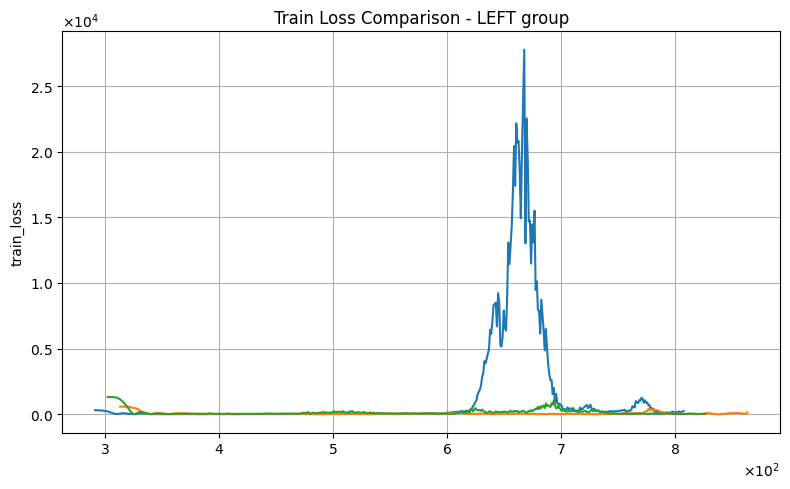


LEFT summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.5,r=norm      1554       187.468498          32.404840      -10.726288        19.906204
w=0.7,r=norm      1646       539.747241         135.759552       -8.673832       445.888245
w=0.3,r=norm      1688       593.484402          48.972965       -2.800585       146.037048


In [95]:


# --- Example usage ---
experiments = {
    "w=0.3,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-32",
    "w=0.5,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-48",
    "w=0.7,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-03",
}

experiments_right = {
    "w=0.3;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-42",
    "w=0.5;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-28",
    "w=0.7;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-15",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    max_points=500
)

C:\Users\es25591\AppData\Local\Temp\ipykernel_11756\2739204159.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


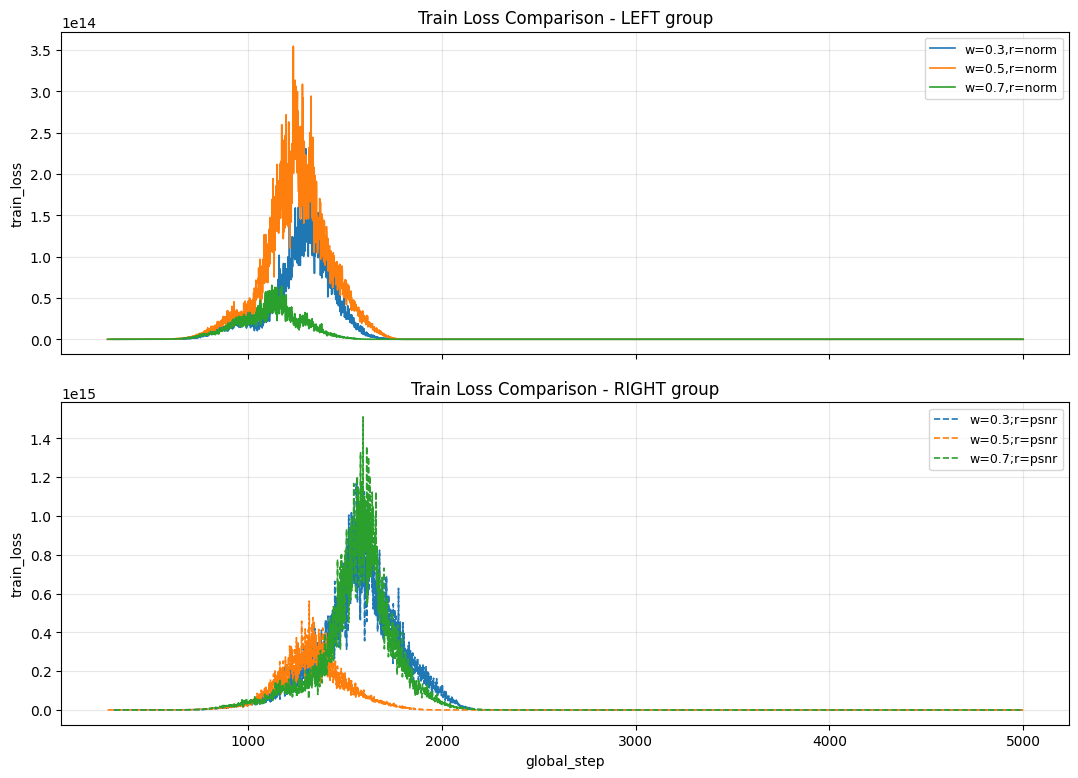


LEFT summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.7,r=norm      4674     3.180009e+12         105.372467       10.469748        25.944859
w=0.3,r=norm      4517     9.234661e+12        1188.951172       48.793262       764.694946
w=0.5,r=norm      4566     1.657601e+13         565.261658       18.668362       258.801178

RIGHT summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.5;r=psnr      4518     2.417343e+13       1.167920e+06     4220.091309     1.120901e+04
w=0.7;r=psnr      4489     6.291312e+13       3.105143e+07   229884.140625     3.548150e+06
w=0.3;r=psnr      4423     7.077004e+13       6.295464e+04     4353.676758     6.684933e+03


In [8]:
# Note: The experiments are disconsidering the warmup phase

# --- Example usage ---
experiments = {
    "w=0.3,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-56",
    "w=0.5,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_13-12",
    "w=0.7,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_13-29",
}

experiments_right = {
    "w=0.3;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_13-45",
    "w=0.5;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_14-01",
    "w=0.7;r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_14-17",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
)

In [9]:
# --- Example usage ---
experiments = {
    "w=0.7,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-09",
    "w=0.5,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-25",
    "w=0.3,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-40",
}

experiments_right = {
    "w=0.7,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-53",
    "w=0.5,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_12-04",
    "w=0.3,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_12-14",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
)

[WARN] Missing file for w=0.7,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-09\metrics\step_metrics.csv
[WARN] Missing file for w=0.5,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-25\metrics\step_metrics.csv
[WARN] Missing file for w=0.3,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-40\metrics\step_metrics.csv
[WARN] Missing file for w=0.7,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_11-53\metrics\step_metrics.csv
[WARN] Missing file for w=0.5,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_12-04\metrics\step_metrics.csv
[WARN] Missing file for w=0.3,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_12-14\metrics\step_metrics.csv
No experiment data loaded.


In [10]:
# Note: The experiments are disconsidering the warmup phase

# --- Example usage ---
experiments = {
    # "w=0.7,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_12-40",
    # "w=0.5,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-02",
    # "w=0.3,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-16"
}

experiments_right = {
    "w=0.7,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-27",
    "w=0.5,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-35",
    "w=0.3,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-44",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
)

[WARN] Missing file for w=0.7,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-27\metrics\step_metrics.csv
[WARN] Missing file for w=0.5,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-35\metrics\step_metrics.csv
[WARN] Missing file for w=0.3,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_13-44\metrics\step_metrics.csv
No experiment data loaded.


In [11]:
# Note: The experiments are disconsidering the warmup phase

# --- Example usage ---
experiments = {
    "w=0.7,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-57",
    "w=0.5,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_15-12",
    "w=0.3,r=norm": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_15-39"
}

experiments_right = {
    "w=0.7,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-24",
    "w=0.5,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-35",
    "w=0.3,r=psnr": "/home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-45",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
)

[WARN] Missing file for w=0.7,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-57\metrics\step_metrics.csv
[WARN] Missing file for w=0.5,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_15-12\metrics\step_metrics.csv
[WARN] Missing file for w=0.3,r=norm: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_15-39\metrics\step_metrics.csv
[WARN] Missing file for w=0.7,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-24\metrics\step_metrics.csv
[WARN] Missing file for w=0.5,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-35\metrics\step_metrics.csv
[WARN] Missing file for w=0.3,r=psnr: /home/eduardo/Workspace/CacheVideoPredict360/Results/2026-03-28_14-45\metrics\step_metrics.csv
No experiment data loaded.


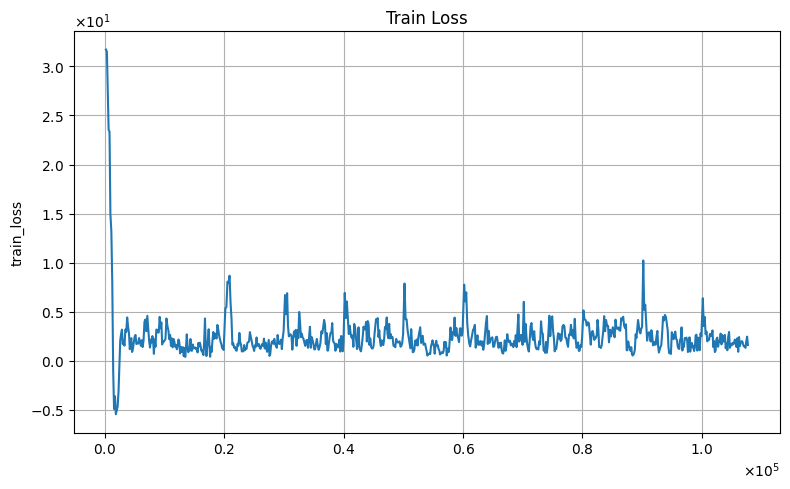


summary (lower is better):
experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
  w=0.3(4)       754         2.428317           2.024847       -5.440809          1.61691


In [282]:
# Note: The experiments are disconsidering the warmup phase

# --- Example usage ---
experiments = {
    "w=0.3(4)": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-04-02_14-56",
}

experiments_right = {}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    
)